# 1. Đọc và tiền xủ lý dữ liệu

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D   

plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('dataset/penguins.csv')
print('Shape ban đầu:', df.shape)
print('Missing values:')
print(df.isnull().sum())

cols_need = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']
df = df.dropna(subset=cols_need).reset_index(drop=True)
print('\nShape sau khi loại NaN:', df.shape)
display(df.head())

Shape ban đầu: (344, 7)
Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Shape sau khi loại NaN: (342, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [2]:
print('Thống kê mô tả:')
display(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].describe().round(2))
print('\nSố lượng theo loài:')
print(df['species'].value_counts())

Thống kê mô tả:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00



Số lượng theo loài:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


In [ ]:

species_list = df['species'].unique()
color_map = {'Adelie': '#185FA5', 'Chinstrap': '#D85A30', 'Gentoo': '#1D9E75'}
colors = df['species'].map(color_map)


import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color_map[s], label=s) for s in species_list]

print('Màu theo loài:', color_map)

Màu theo loài: {'Adelie': '#185FA5', 'Chinstrap': '#D85A30', 'Gentoo': '#1D9E75'}


---
## 2 – 3D Scatter Chart
`bill_length_mm` (X) × `bill_depth_mm` (Y) × `flipper_length_mm` (Z)

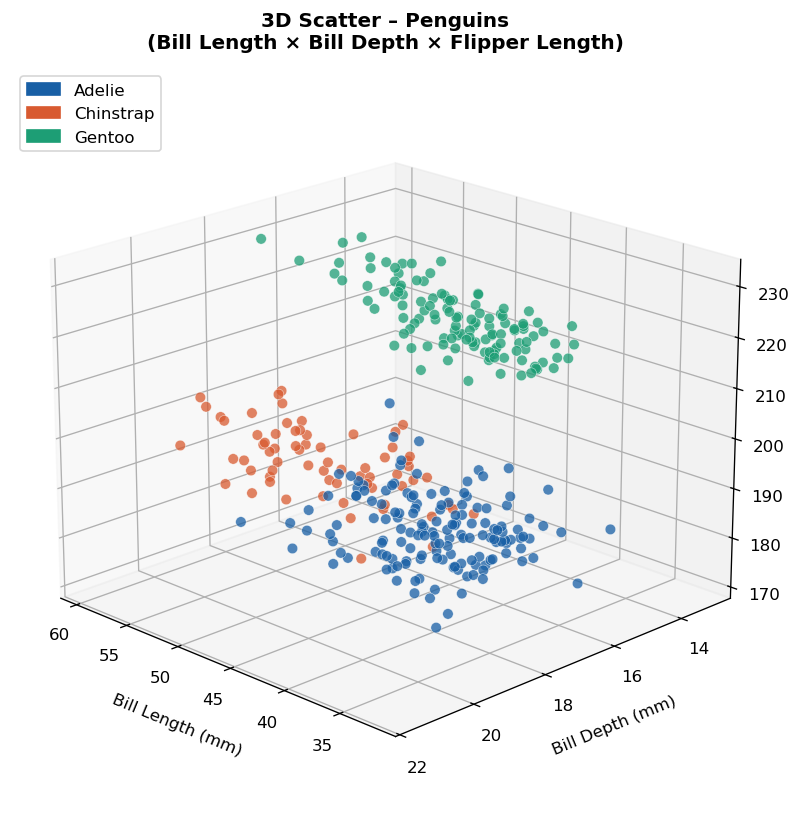

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for species in species_list:
    sub = df[df['species'] == species]
    ax.scatter(
        sub['bill_length_mm'],
        sub['bill_depth_mm'],
        sub['flipper_length_mm'],
        c=color_map[species],
        label=species,
        s=40,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_xlabel('Bill Length (mm)', fontsize=10, labelpad=8)
ax.set_ylabel('Bill Depth (mm)', fontsize=10, labelpad=8)
ax.set_zlabel('Flipper Length (mm)', fontsize=10, labelpad=8)
ax.set_title('3D Scatter – Penguins\n(Bill Length × Bill Depth × Flipper Length)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(handles=legend_handles, loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=135)   # góc nhìn

plt.tight_layout()
plt.savefig('scatter3d_penguins.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét – 3D Scatter:**

| Loài | Bill Length | Bill Depth | Flipper Length | Nhận xét tổng |
|---|---|---|---|---|
| **Adelie** (xanh) | Ngắn ~38mm | Sâu ~18mm | Trung bình ~190mm | Cụm chặt, dễ phân biệt |
| **Chinstrap** (cam) | Dài ~49mm | Sâu ~18mm | Trung bình ~196mm | Giống Adelie về bill_depth, khác bill_length |
| **Gentoo** (xanh lá) | Dài ~47mm | Nông ~15mm | Dài nhất ~217mm | Tách biệt hẳn nhờ flipper dài và bill nông |

- **Gentoo** tạo cụm riêng biệt và dễ phân tách nhất trên không gian 3D, đặc biệt ở trục `flipper_length_mm`.
- **Adelie và Chinstrap** có phần chồng lấp ở chiều `bill_depth` nhưng tách biệt ở chiều `bill_length`.
- Không gian 3D giúp thấy rõ **3 cụm** tương ứng 3 loài mà biểu đồ 2D không thể hiện đầy đủ.

---
## 3 – 4D Scatter Chart
`bill_length_mm` (X) × `bill_depth_mm` (Y) × `flipper_length_mm` (Z) + `body_mass_g` (kích thước điểm)

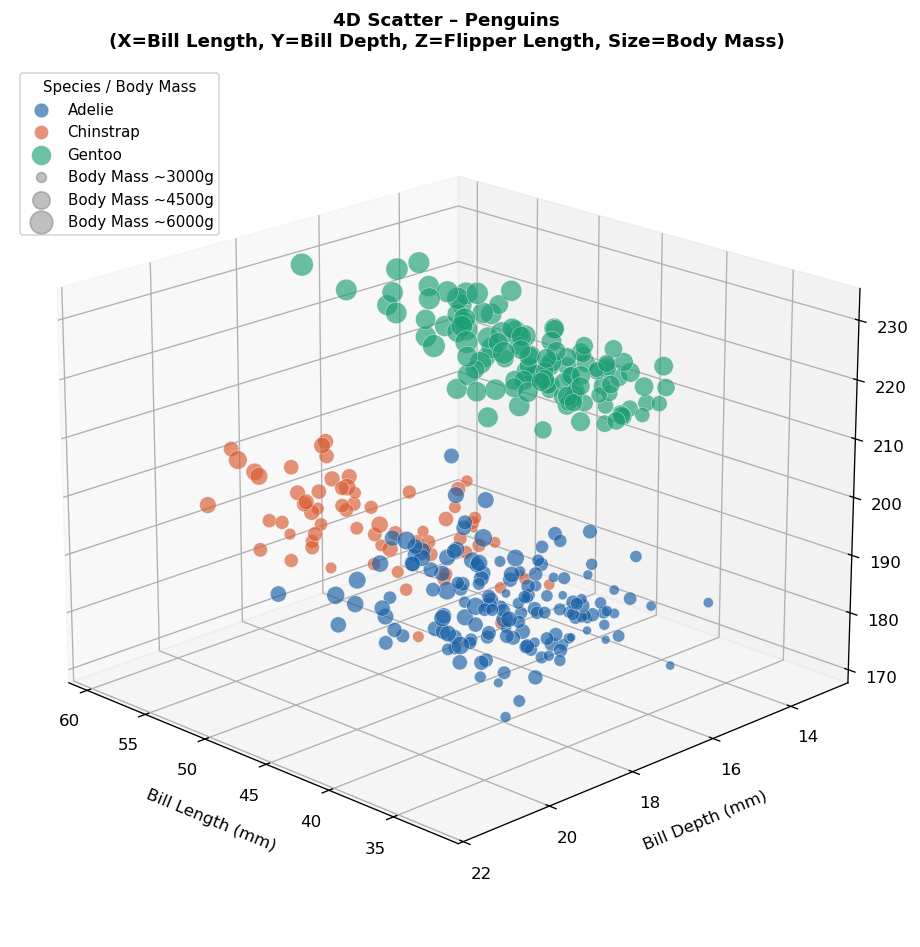

In [ ]:

mass = df['body_mass_g']
size_scaled = 20 + 180 * (mass - mass.min()) / (mass.max() - mass.min())

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for species in species_list:
    mask = df['species'] == species
    sc = ax.scatter(
        df.loc[mask, 'bill_length_mm'],
        df.loc[mask, 'bill_depth_mm'],
        df.loc[mask, 'flipper_length_mm'],
        c=color_map[species],
        s=size_scaled[mask],
        label=species,
        alpha=0.65,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_xlabel('Bill Length (mm)', fontsize=10, labelpad=8)
ax.set_ylabel('Bill Depth (mm)', fontsize=10, labelpad=8)
ax.set_zlabel('Flipper Length (mm)', fontsize=10, labelpad=8)
ax.set_title('4D Scatter – Penguins\n(X=Bill Length, Y=Bill Depth, Z=Flipper Length, Size=Body Mass)',
             fontsize=11, fontweight='bold', pad=12)


ax.legend(handles=legend_handles, loc='upper left', fontsize=10, title='Species')


for mass_val, lbl in [(3000,'3000g'),(4500,'4500g'),(6000,'6000g')]:
    s_example = 20 + 180*(mass_val - mass.min())/(mass.max()-mass.min())
    ax.scatter([], [], [], s=s_example, c='gray', alpha=0.5, label=f'Body Mass ~{lbl}')
ax.legend(loc='upper left', fontsize=9, title='Species / Body Mass', title_fontsize=9)

ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.savefig('scatter4d_penguins.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét – 4D Scatter:**

- **Chiều thứ 4 (body_mass_g)** được mã hóa bằng **kích thước điểm** → điểm to = chim nặng hơn.
- **Gentoo** không chỉ có flipper dài nhất mà còn có **điểm to nhất** → khối lượng cơ thể lớn nhất (~5000–6300g).
- **Adelie và Chinstrap** có điểm nhỏ hơn hẳn → khối lượng cơ thể thấp hơn (~3000–4000g).
- 4D scatter cho thấy **Gentoo vượt trội về tất cả 4 chỉ số đo lường kích thước cơ thể** so với 2 loài còn lại.
- **Chinstrap** có bill dài nhưng cơ thể không nặng bằng Gentoo → biểu đồ 2D sẽ dễ nhầm lẫn, biểu đồ 4D làm rõ điều này.
- Nhược điểm của biểu đồ 4D: khi điểm chồng lấp (Adelie & Chinstrap) thì kích thước điểm khó đọc chính xác.

---
## 4 – Xem từ nhiều góc nhìn khác nhau

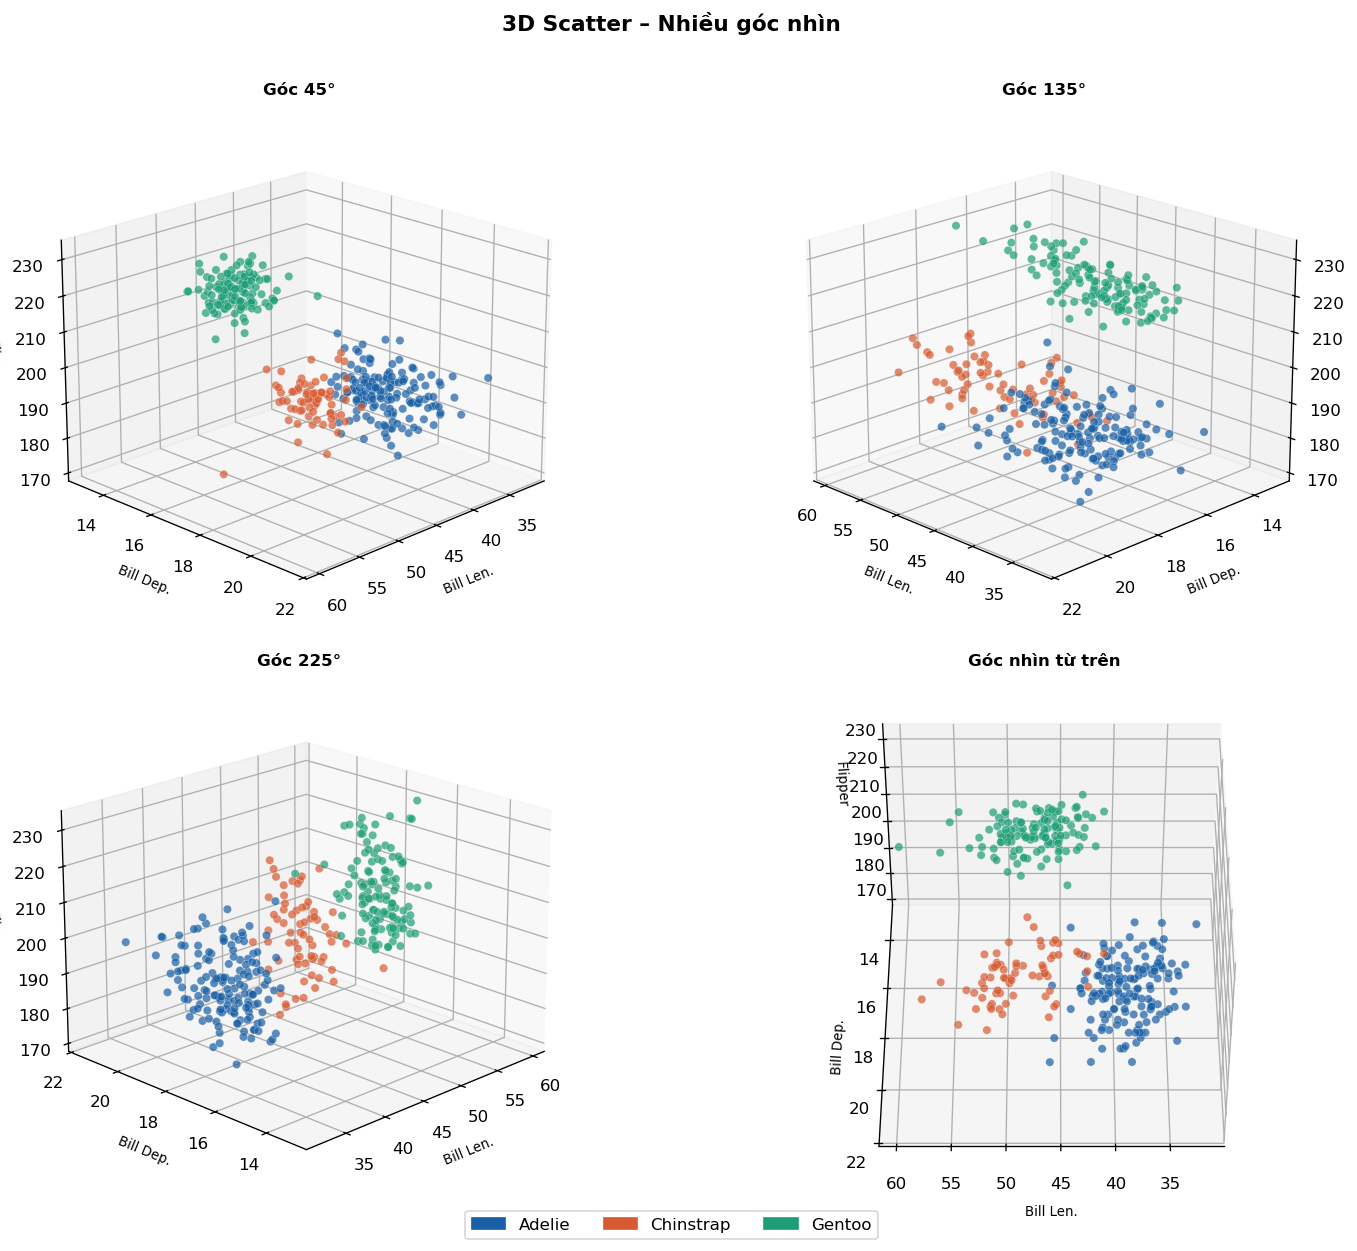

In [6]:

angles = [(20, 45), (20, 135), (20, 225), (45, 90)]
titles = ['Góc 45°', 'Góc 135°', 'Góc 225°', 'Góc nhìn từ trên']

fig = plt.figure(figsize=(14, 10))

for idx, ((elev, azim), title) in enumerate(zip(angles, titles)):
    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    for species in species_list:
        sub = df[df['species'] == species]
        ax.scatter(
            sub['bill_length_mm'], sub['bill_depth_mm'], sub['flipper_length_mm'],
            c=color_map[species], s=25, alpha=0.7,
            edgecolors='white', linewidths=0.2
        )
    ax.set_xlabel('Bill Len.', fontsize=8)
    ax.set_ylabel('Bill Dep.', fontsize=8)
    ax.set_zlabel('Flipper', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

fig.suptitle('3D Scatter – Nhiều góc nhìn', fontsize=13, fontweight='bold', y=1.01)
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('scatter3d_multiview.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét – Nhiều góc nhìn:**
- Vẽ từ nhiều góc giúp xác nhận rằng **3 cụm tồn tại rõ ràng trong không gian 3D**, không phải do góc nhìn ngẫu nhiên.
- Góc nhìn từ trên (elev=45) cho thấy sự tách biệt rõ nhất giữa Gentoo và 2 loài còn lại theo trục Bill Length.
- Không có cụm nào chồng lấp hoàn toàn → 3 đặc trưng đo lường (bill_length, bill_depth, flipper_length) **đủ để phân loại 3 loài chim cánh cụt**.